# Round 5 Price Path Exploration

This notebook loads the Round 5 price data from `datasets/round5` and visualizes the mid-price paths for products across days 2, 3, and 4.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")

base_path = Path("../datasets/round5")
price_files = {
    2: "prices_round_5_day_2.csv",
    3: "prices_round_5_day_3.csv",
    4: "prices_round_5_day_4.csv",
}

all_prices = []
for day, file_name in price_files.items():
    file_path = base_path / file_name
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = df["timestamp"].astype(int)
    all_prices.append(df)

all_prices = pd.concat(all_prices, ignore_index=True)

all_prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,PEBBLES_L,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
1,2,0,SNACKPACK_RASPBERRY,9992,36,9990.0,45.0,NaN,NaN,10008,36,10010.0,45.0,NaN,NaN,10000.0,0.0
2,2,0,UV_VISOR_RED,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0
3,2,0,PEBBLES_M,9994,13,9992.0,21.0,NaN,NaN,10006,13,10008.0,21.0,NaN,NaN,10000.0,0.0
4,2,0,GALAXY_SOUNDS_DARK_MATTER,9994,22,9992.0,26.0,NaN,NaN,10006,22,10008.0,26.0,NaN,NaN,10000.0,0.0


In [2]:
print("Loaded price data shape:", all_prices.shape)
print("Days in dataset:", sorted(all_prices["day"].unique()))
print("Unique products:", all_prices["product"].nunique())
print("Rows per day:")
print(all_prices.groupby("day")["product"].nunique())

Loaded price data shape: (1500000, 17)
Days in dataset: [np.int64(2), np.int64(3), np.int64(4)]
Unique products: 50
Rows per day:
day
2    50
3    50
4    50
Name: product, dtype: int64


## Sector-Based Price Path Analysis

Now we group products into logical sectors and visualize their price paths individually and as sector aggregates.

In [3]:
# Define the 10 sectors with their products
sectors = {
    "Food & Nutrition (Snackpacks)": [
        "SNACKPACK_CHOCOLATE",
        "SNACKPACK_PISTACHIO",
        "SNACKPACK_RASPBERRY",
        "SNACKPACK_STRAWBERRY",
        "SNACKPACK_VANILLA",
    ],
    "Specialty Consumables (Oxygen Shakes)": [
        "OXYGEN_SHAKE_CHOCOLATE",
        "OXYGEN_SHAKE_EVENING_BREATH",
        "OXYGEN_SHAKE_GARLIC",
        "OXYGEN_SHAKE_MINT",
        "OXYGEN_SHAKE_MORNING_BREATH",
    ],
    "Entertainment & Media (Galaxy Sounds)": [
        "GALAXY_SOUNDS_BLACK_HOLES",
        "GALAXY_SOUNDS_DARK_MATTER",
        "GALAXY_SOUNDS_PLANETARY_RINGS",
        "GALAXY_SOUNDS_SOLAR_FLAMES",
        "GALAXY_SOUNDS_SOLAR_WINDS",
    ],
    "Protective Wearables (UV Visors)": [
        "UV_VISOR_AMBER",
        "UV_VISOR_MAGENTA",
        "UV_VISOR_ORANGE",
        "UV_VISOR_RED",
        "UV_VISOR_YELLOW",
    ],
    "Communications (Translators)": [
        "TRANSLATOR_ASTRO_BLACK",
        "TRANSLATOR_ECLIPSE_CHARCOAL",
        "TRANSLATOR_GRAPHITE_MIST",
        "TRANSLATOR_SPACE_GRAY",
        "TRANSLATOR_VOID_BLUE",
    ],
    "Domestic Robotics (Robots)": [
        "ROBOT_DISHES",
        "ROBOT_IRONING",
        "ROBOT_LAUNDRY",
        "ROBOT_MOPPING",
        "ROBOT_VACUUMING",
    ],
    "Furnishings & Habitation (Sleep Pods)": [
        "SLEEP_POD_COTTON",
        "SLEEP_POD_LAMB_WOOL",
        "SLEEP_POD_NYLON",
        "SLEEP_POD_POLYESTER",
        "SLEEP_POD_SUEDE",
    ],
    "Electronics & Components (Microchips)": [
        "MICROCHIP_CIRCLE",
        "MICROCHIP_OVAL",
        "MICROCHIP_RECTANGLE",
        "MICROCHIP_SQUARE",
        "MICROCHIP_TRIANGLE",
    ],
    "Structural Components (Panels)": [
        "PANEL_1X2",
        "PANEL_1X4",
        "PANEL_2X2",
        "PANEL_2X4",
        "PANEL_4X4",
    ],
    "Raw Materials (Pebbles)": [
        "PEBBLES_XL",
        "PEBBLES_L",
        "PEBBLES_M",
        "PEBBLES_S",
        "PEBBLES_XS",
    ],
}

Existing products: ['GALAXY_SOUNDS_BLACK_HOLES', 'GALAXY_SOUNDS_DARK_MATTER', 'GALAXY_SOUNDS_PLANETARY_RINGS', 'GALAXY_SOUNDS_SOLAR_FLAMES', 'GALAXY_SOUNDS_SOLAR_WINDS', 'MICROCHIP_CIRCLE', 'MICROCHIP_OVAL', 'MICROCHIP_RECTANGLE', 'MICROCHIP_SQUARE', 'MICROCHIP_TRIANGLE', 'OXYGEN_SHAKE_CHOCOLATE', 'OXYGEN_SHAKE_EVENING_BREATH', 'OXYGEN_SHAKE_GARLIC', 'OXYGEN_SHAKE_MINT', 'OXYGEN_SHAKE_MORNING_BREATH', 'PANEL_1X2', 'PANEL_1X4', 'PANEL_2X2', 'PANEL_2X4', 'PANEL_4X4', 'PEBBLES_L', 'PEBBLES_M', 'PEBBLES_S', 'PEBBLES_XL', 'PEBBLES_XS', 'ROBOT_DISHES', 'ROBOT_IRONING', 'ROBOT_LAUNDRY', 'ROBOT_MOPPING', 'ROBOT_VACUUMING', 'SLEEP_POD_COTTON', 'SLEEP_POD_LAMB_WOOL', 'SLEEP_POD_NYLON', 'SLEEP_POD_POLYESTER', 'SLEEP_POD_SUEDE', 'SNACKPACK_CHOCOLATE', 'SNACKPACK_PISTACHIO', 'SNACKPACK_RASPBERRY', 'SNACKPACK_STRAWBERRY', 'SNACKPACK_VANILLA', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_VOID_BLUE', 'UV_VISOR_AMBER', 'UV_VIS

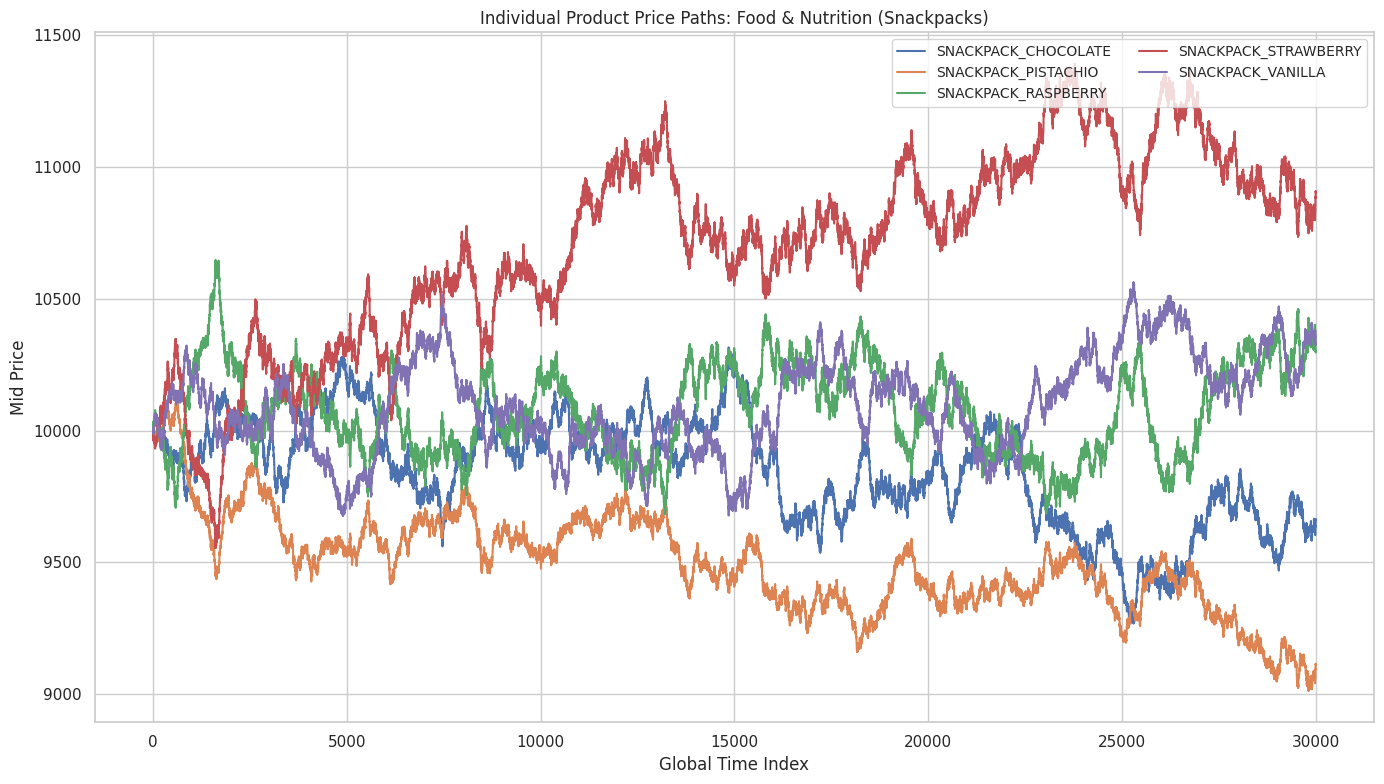

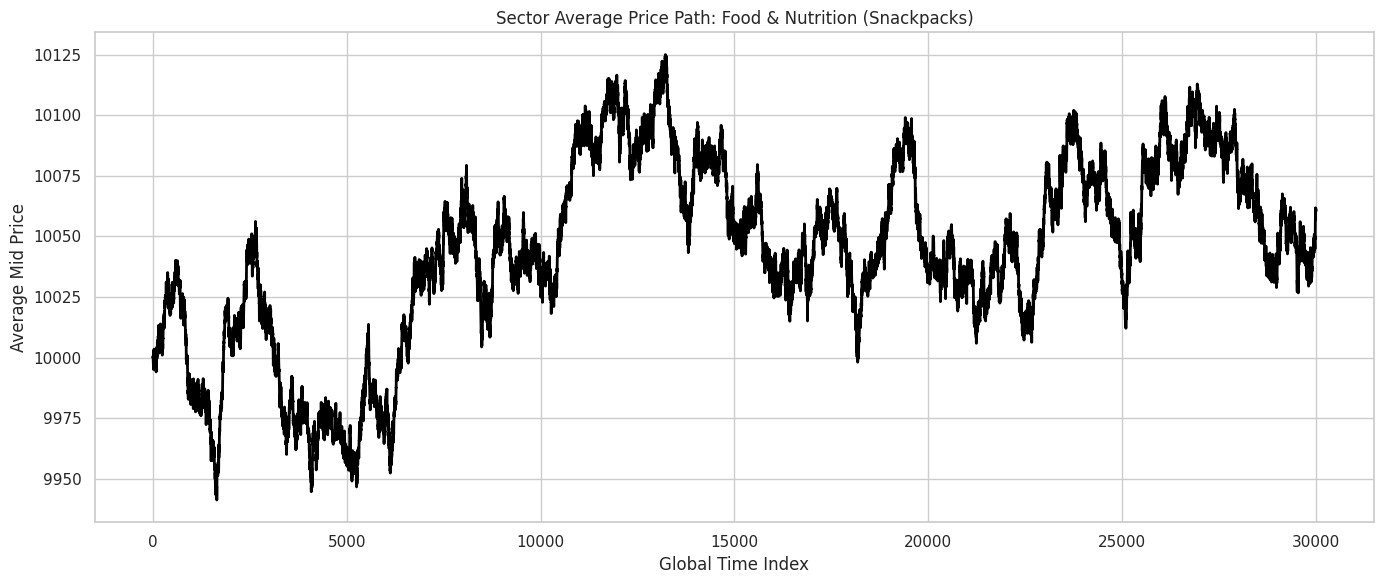

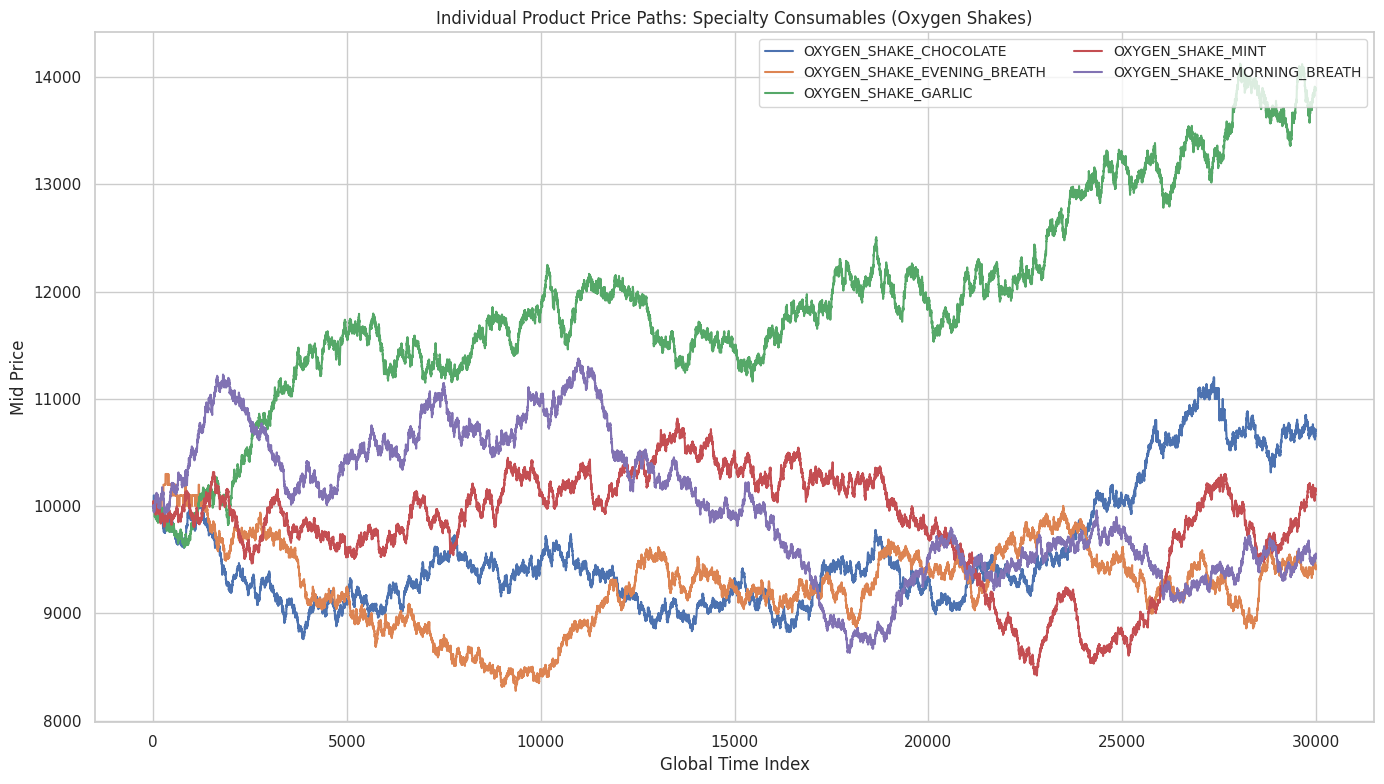

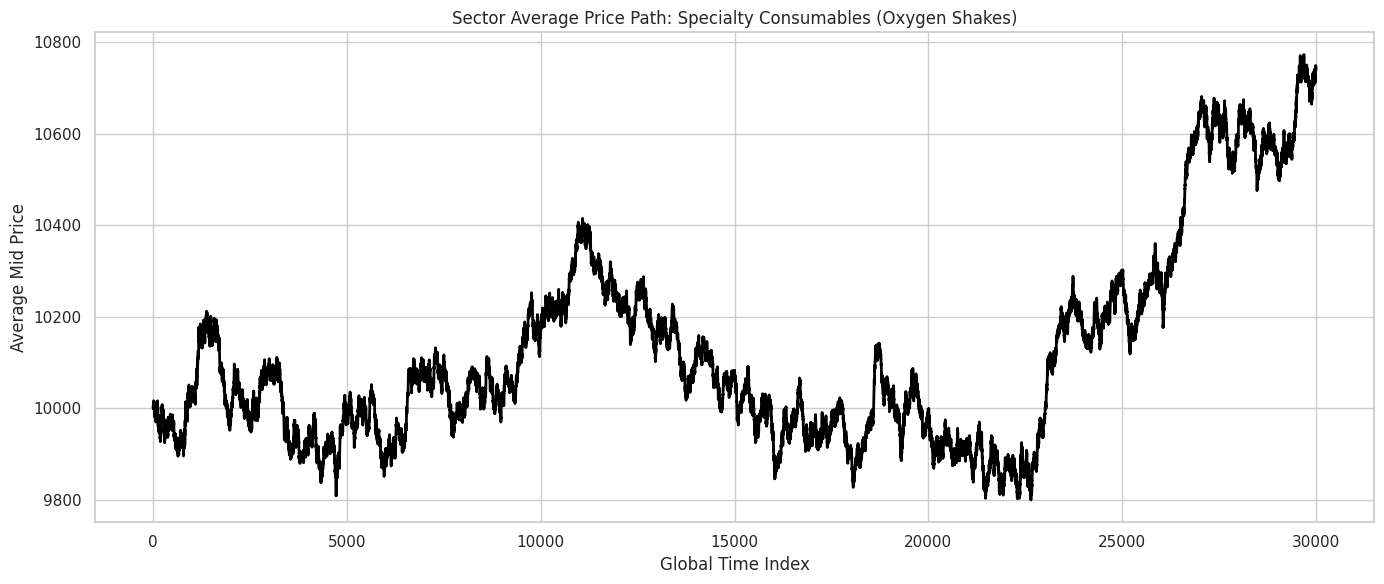

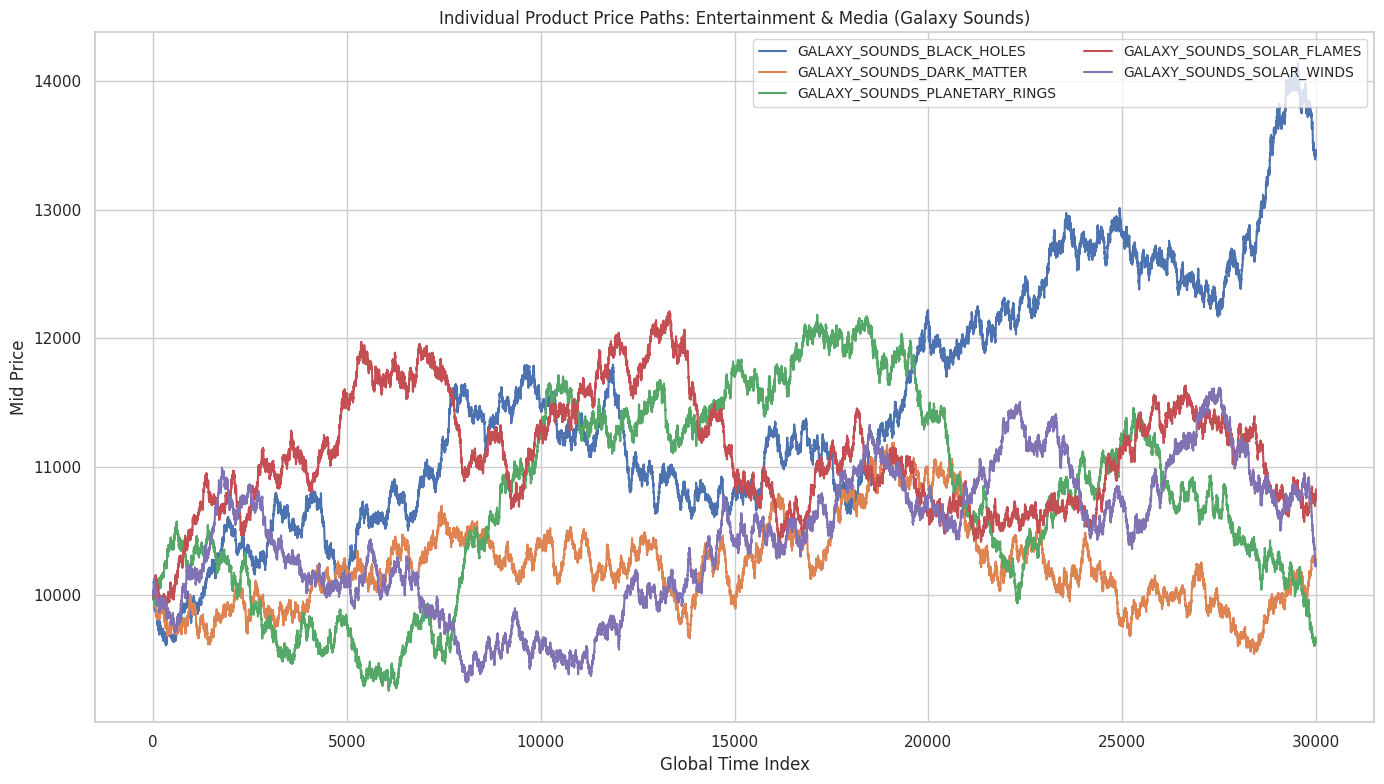

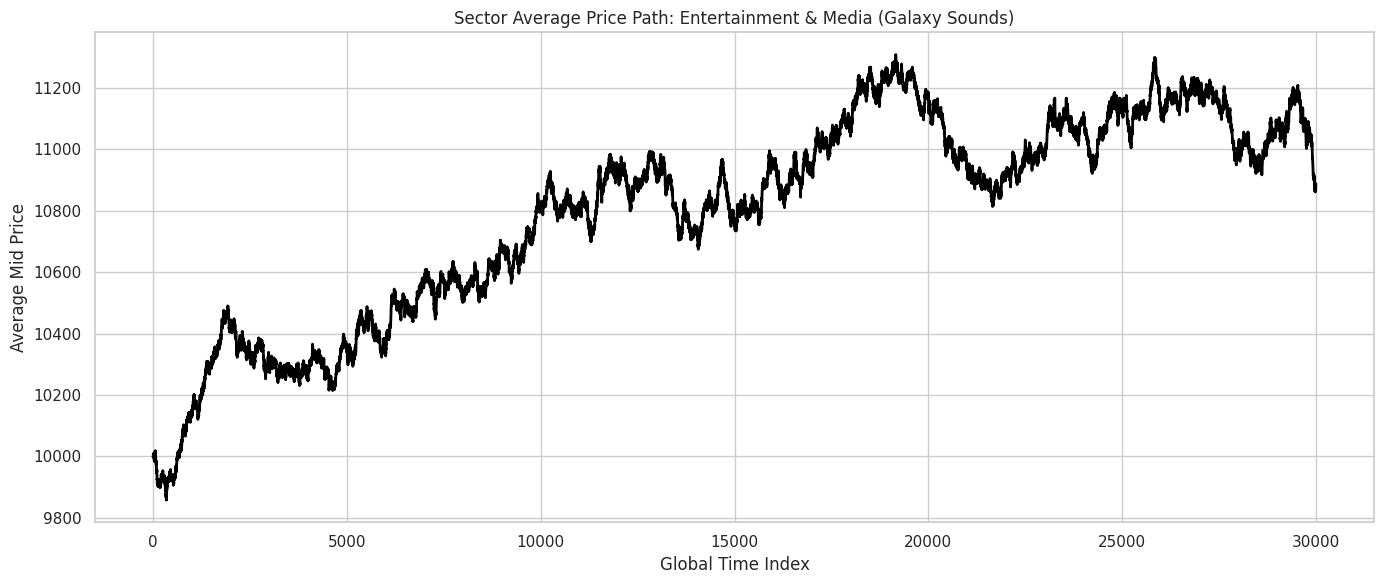

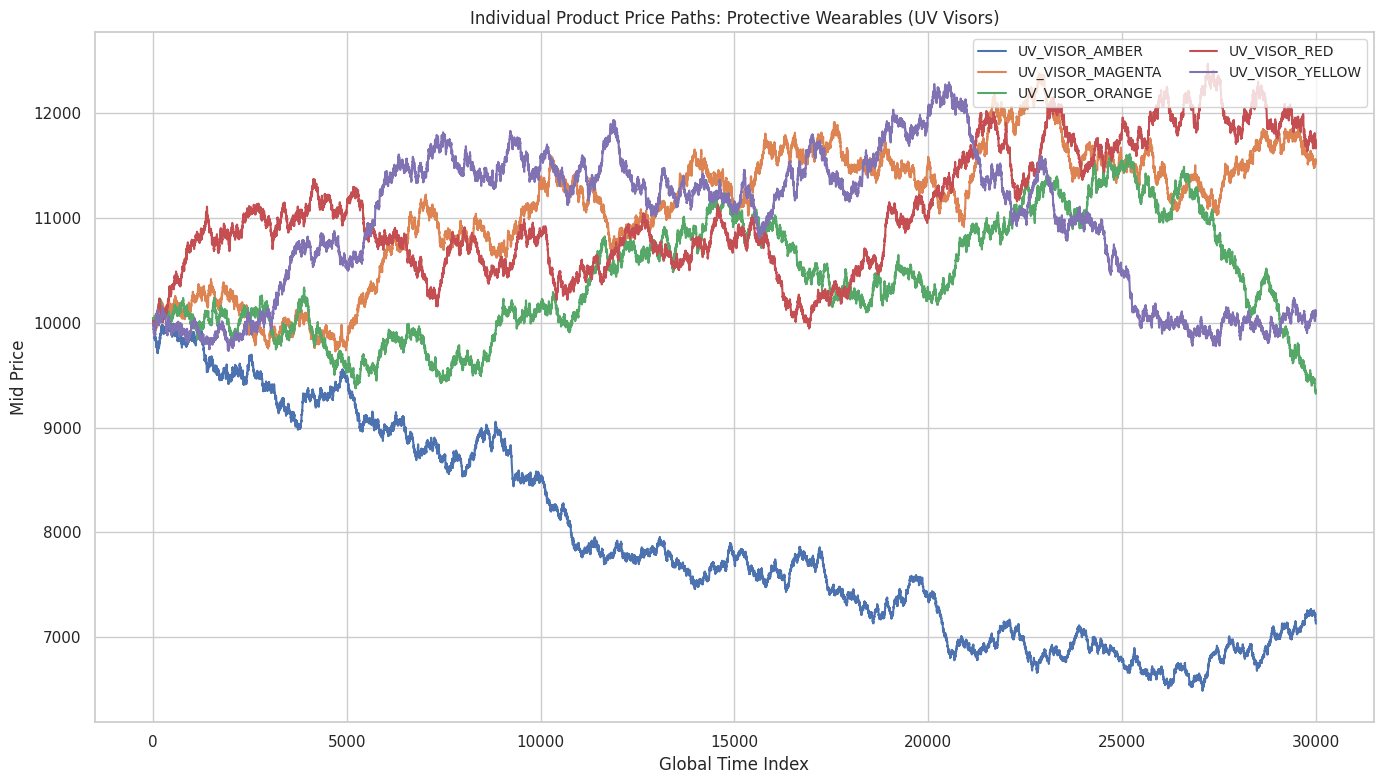

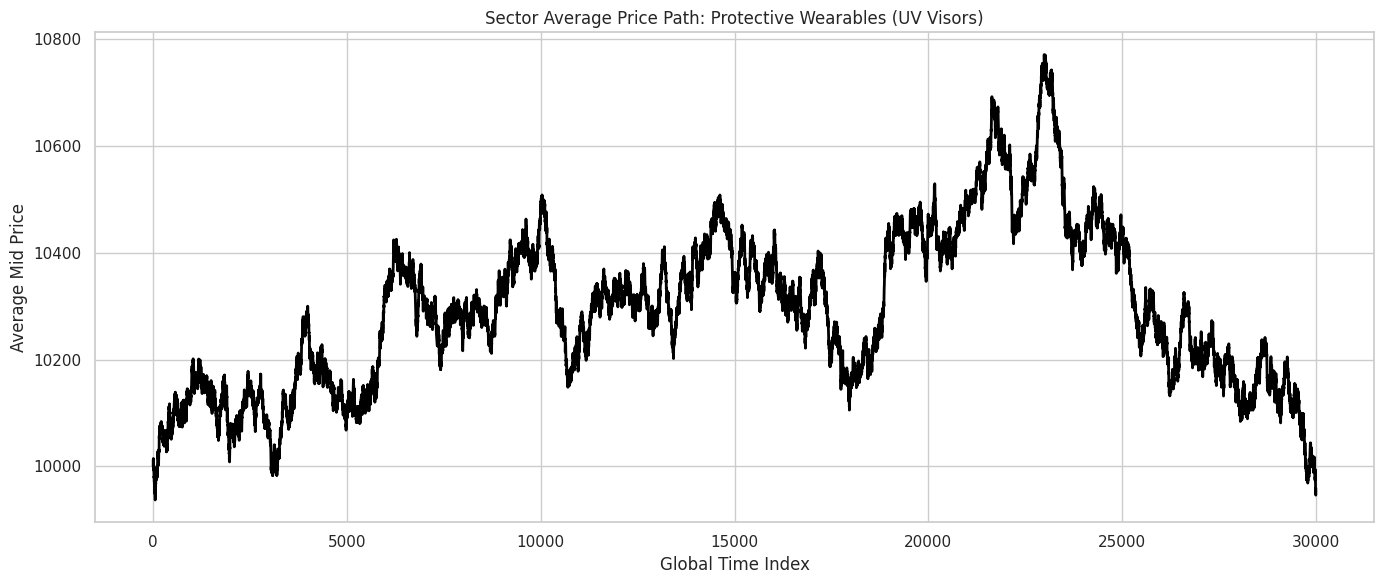

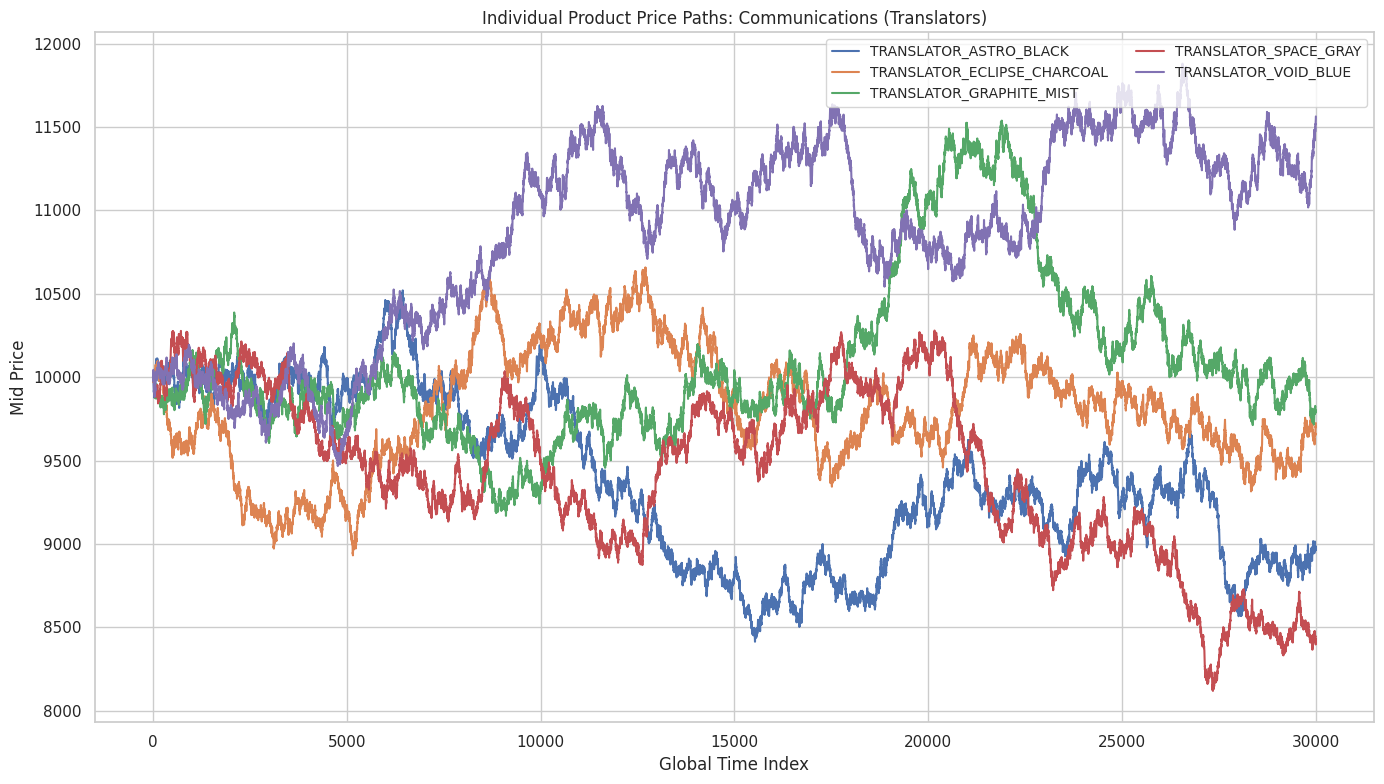

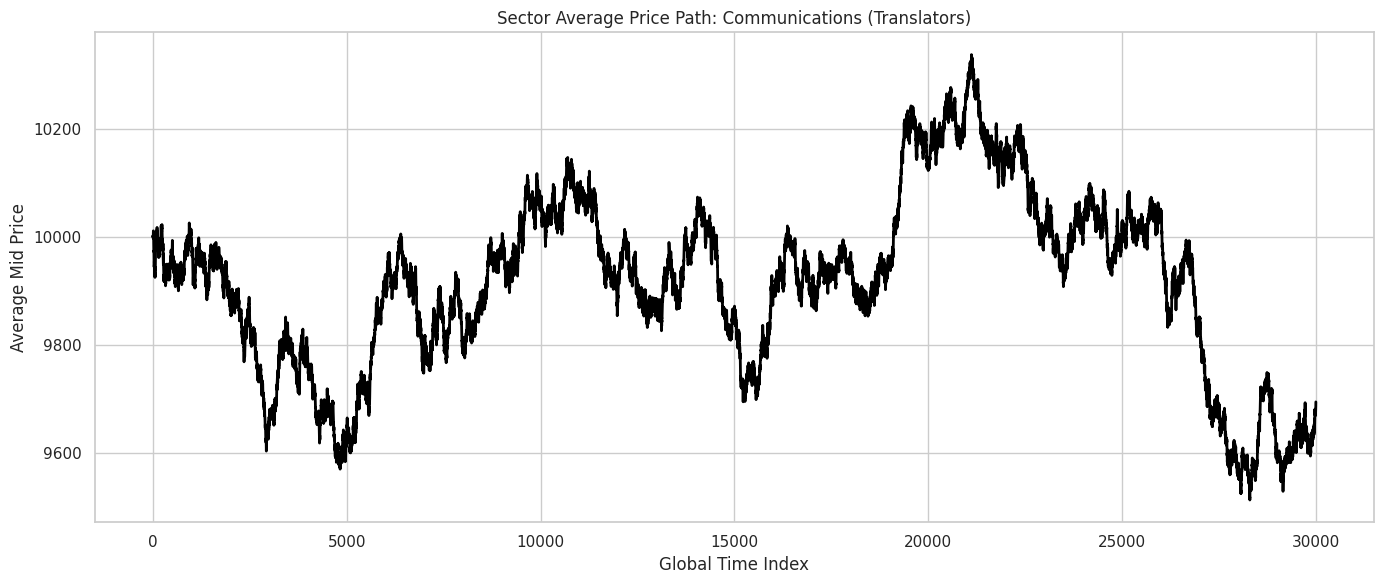

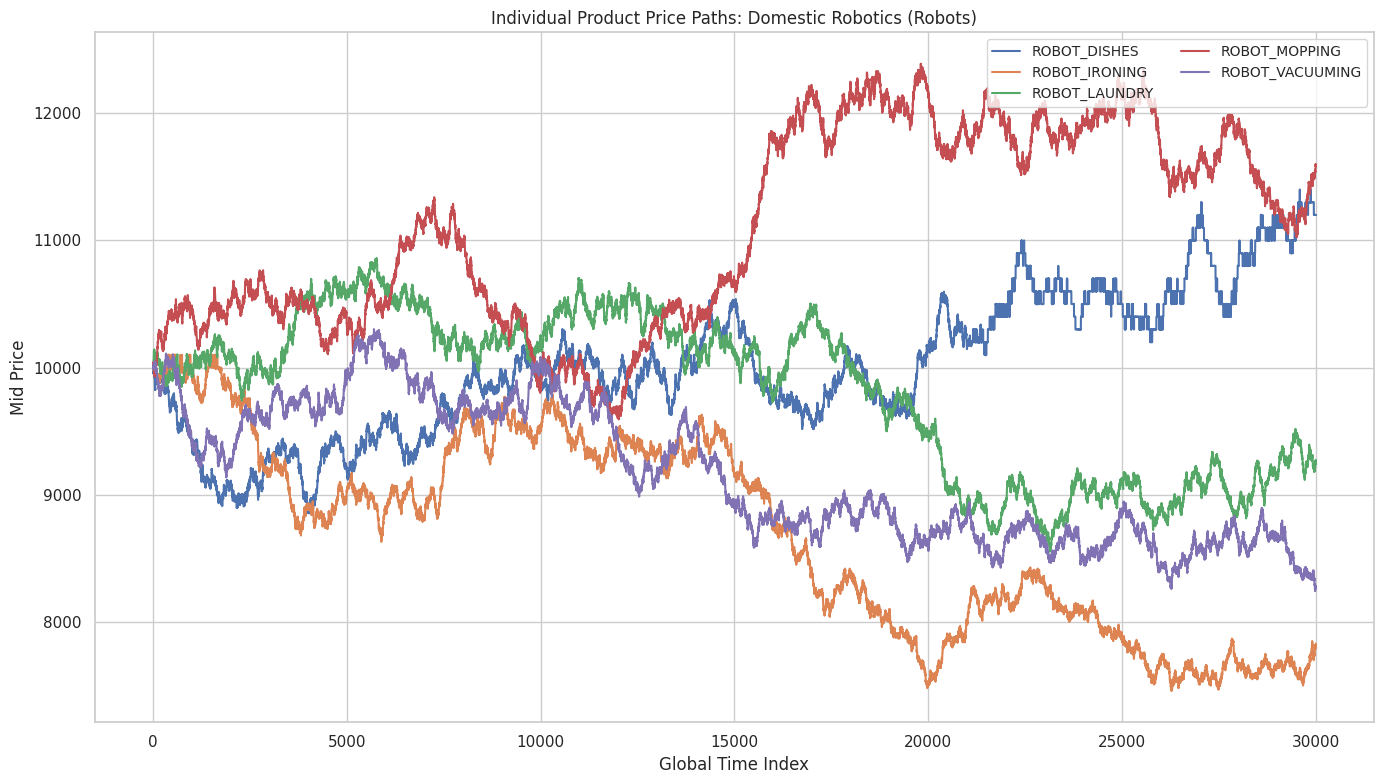

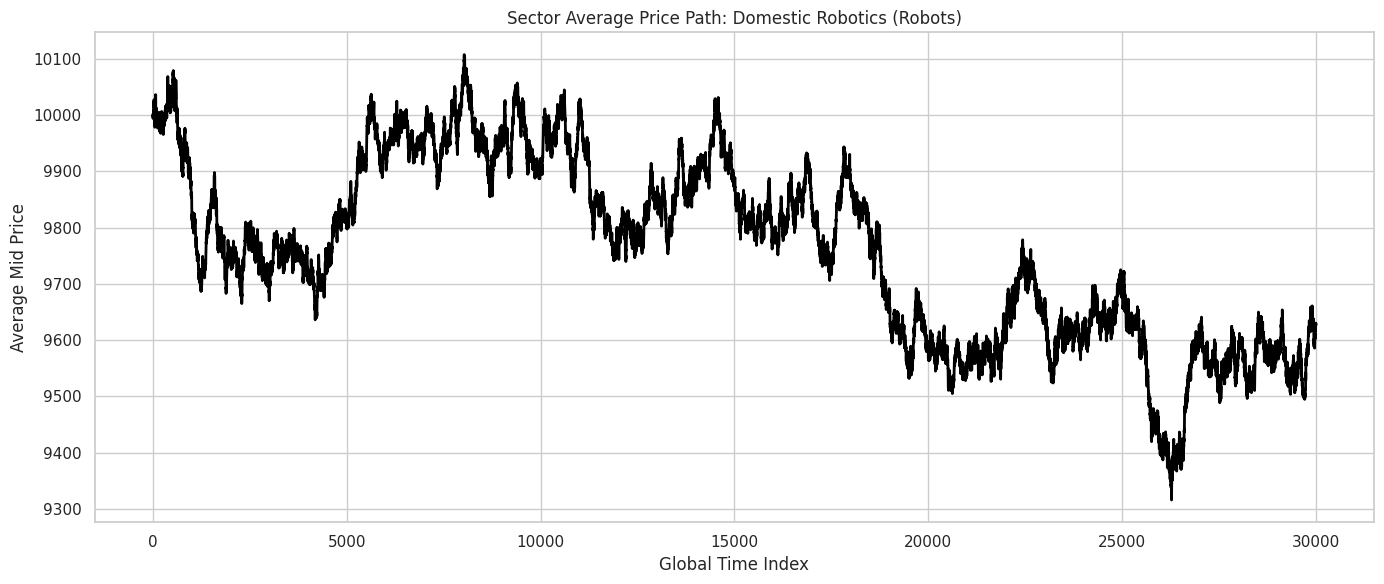

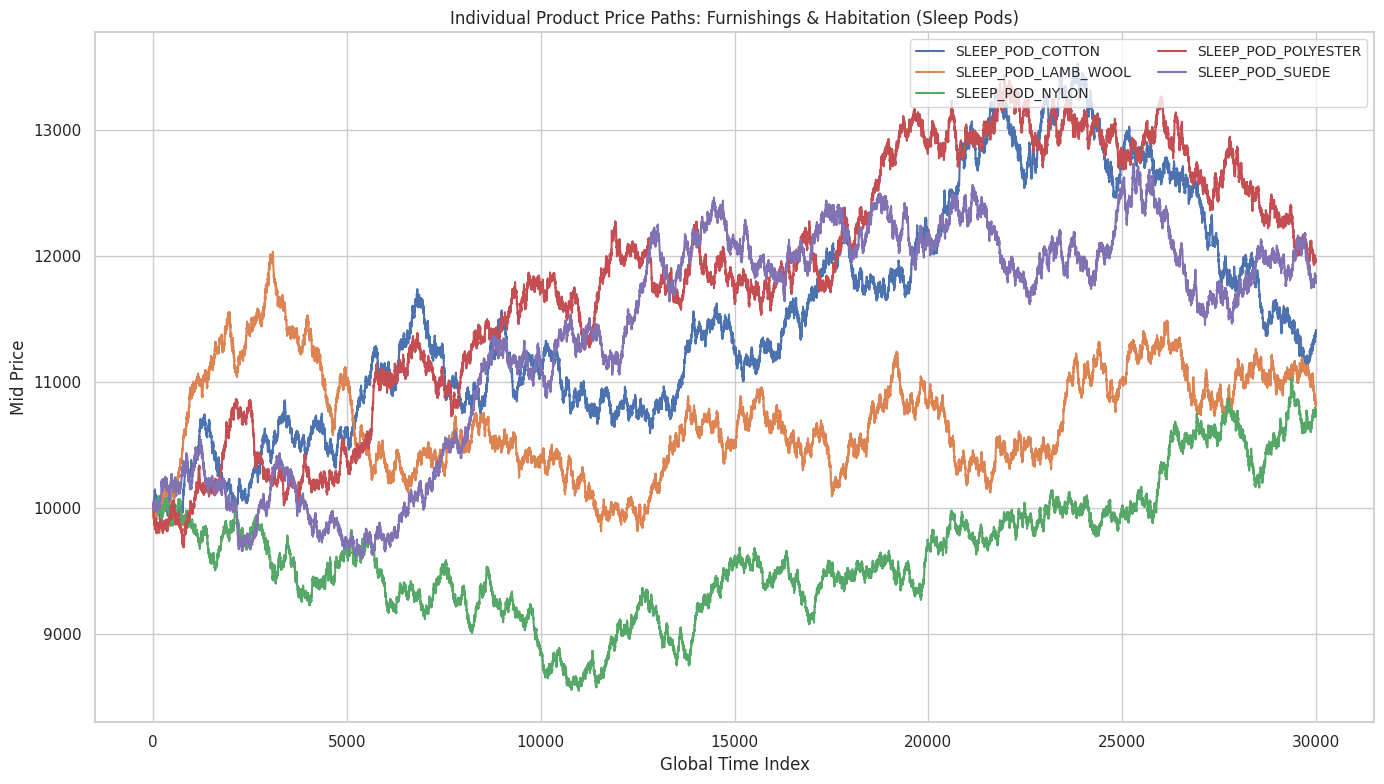

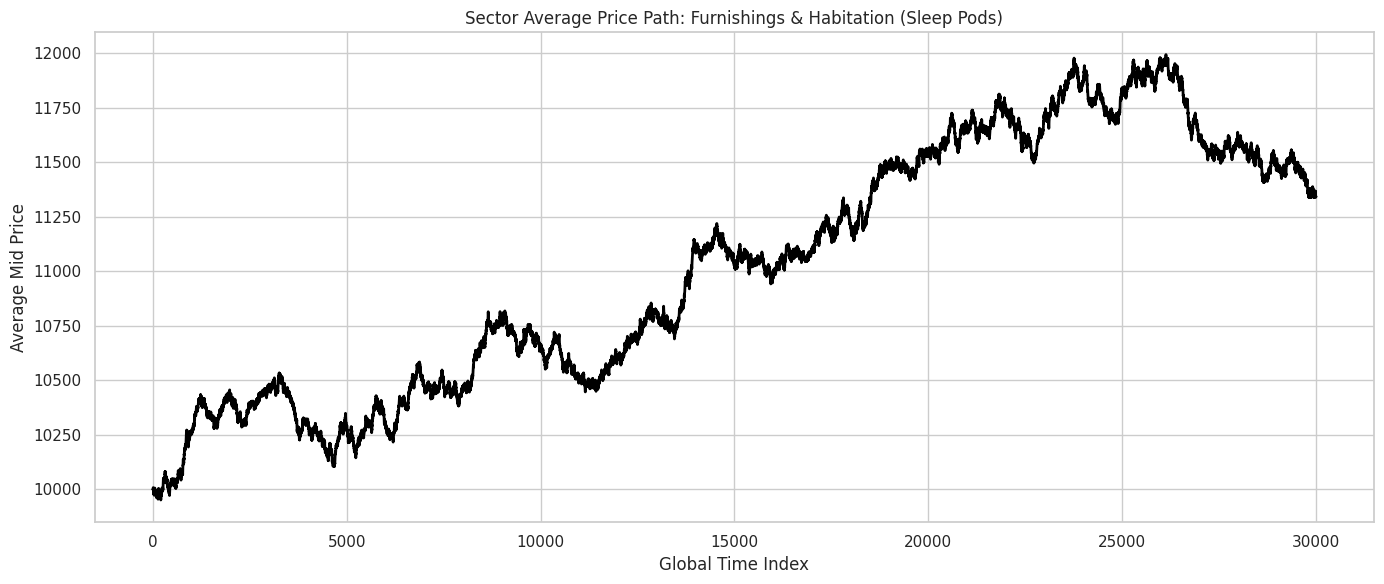

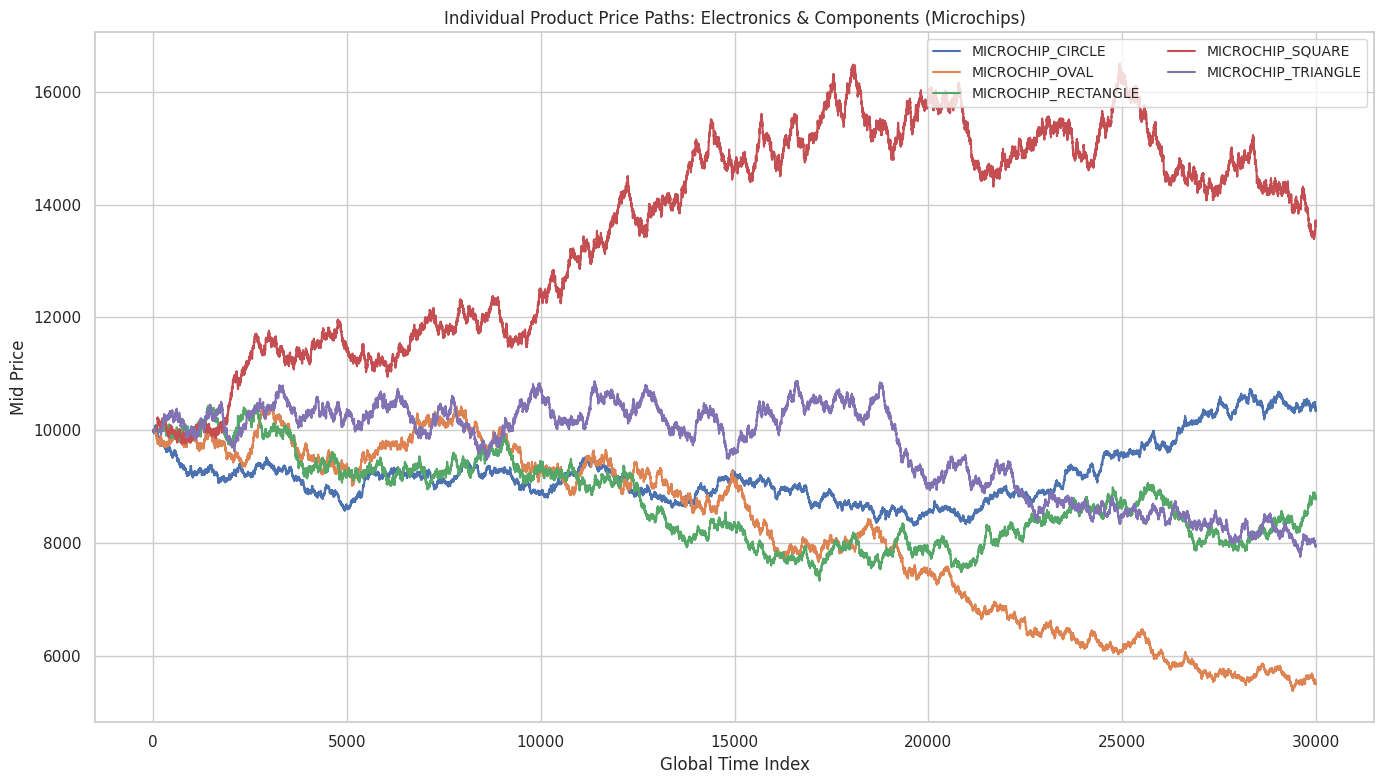

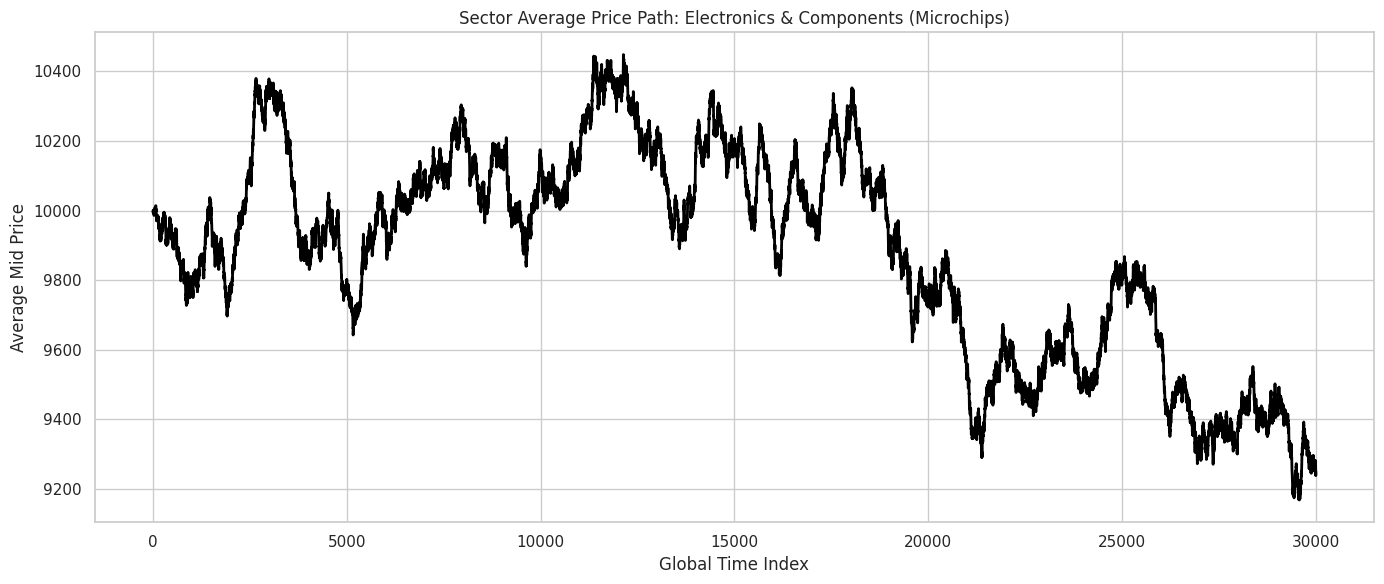

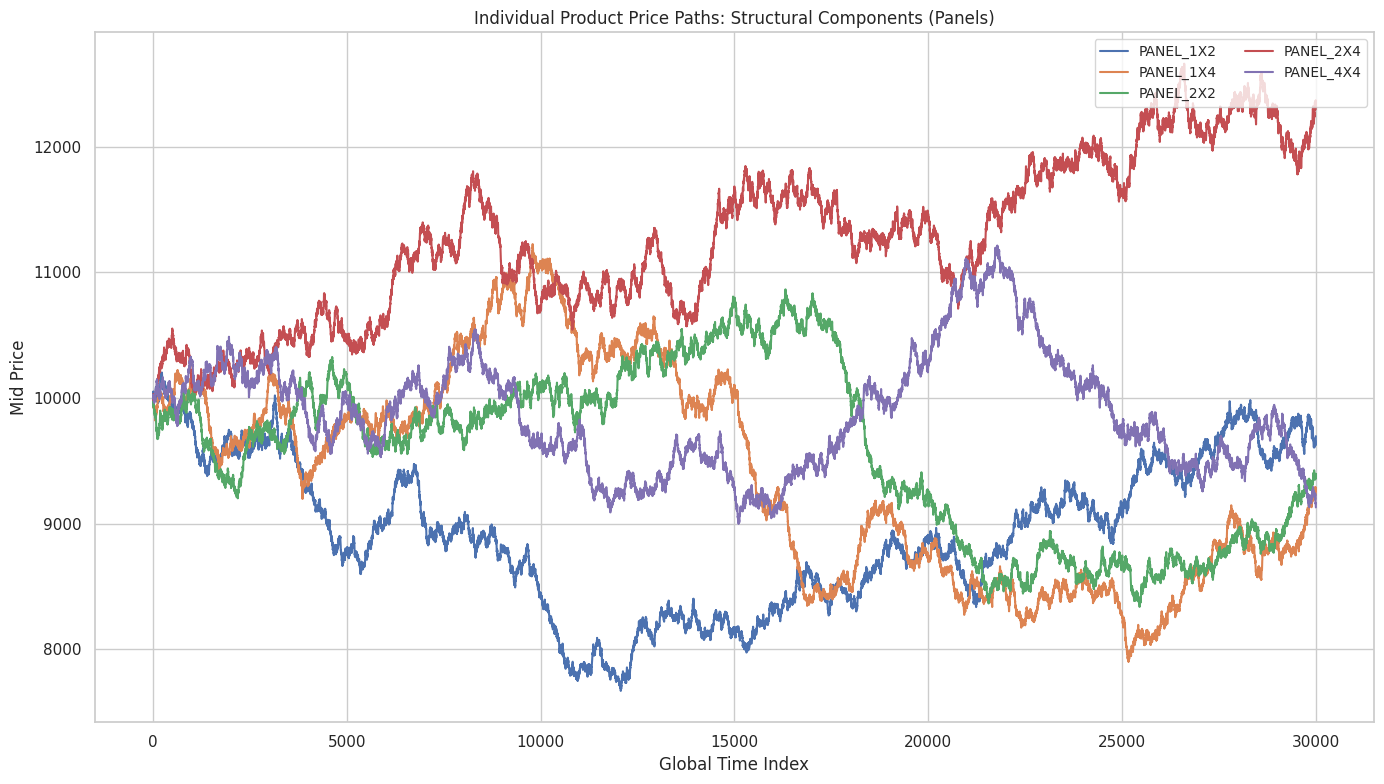

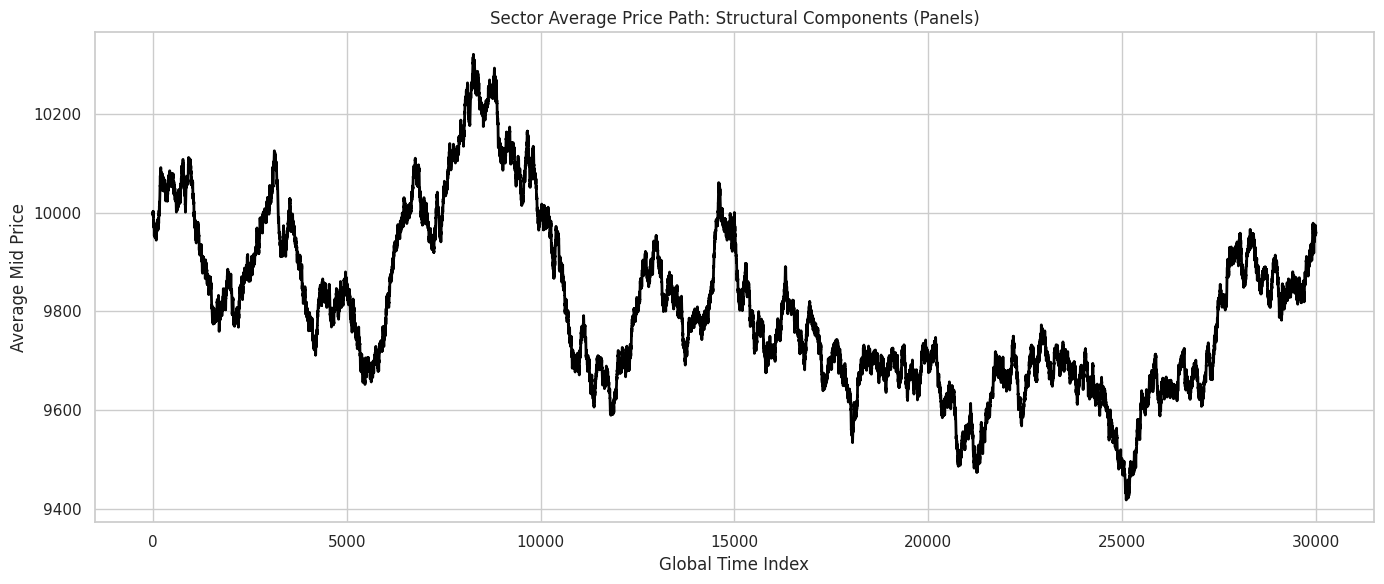

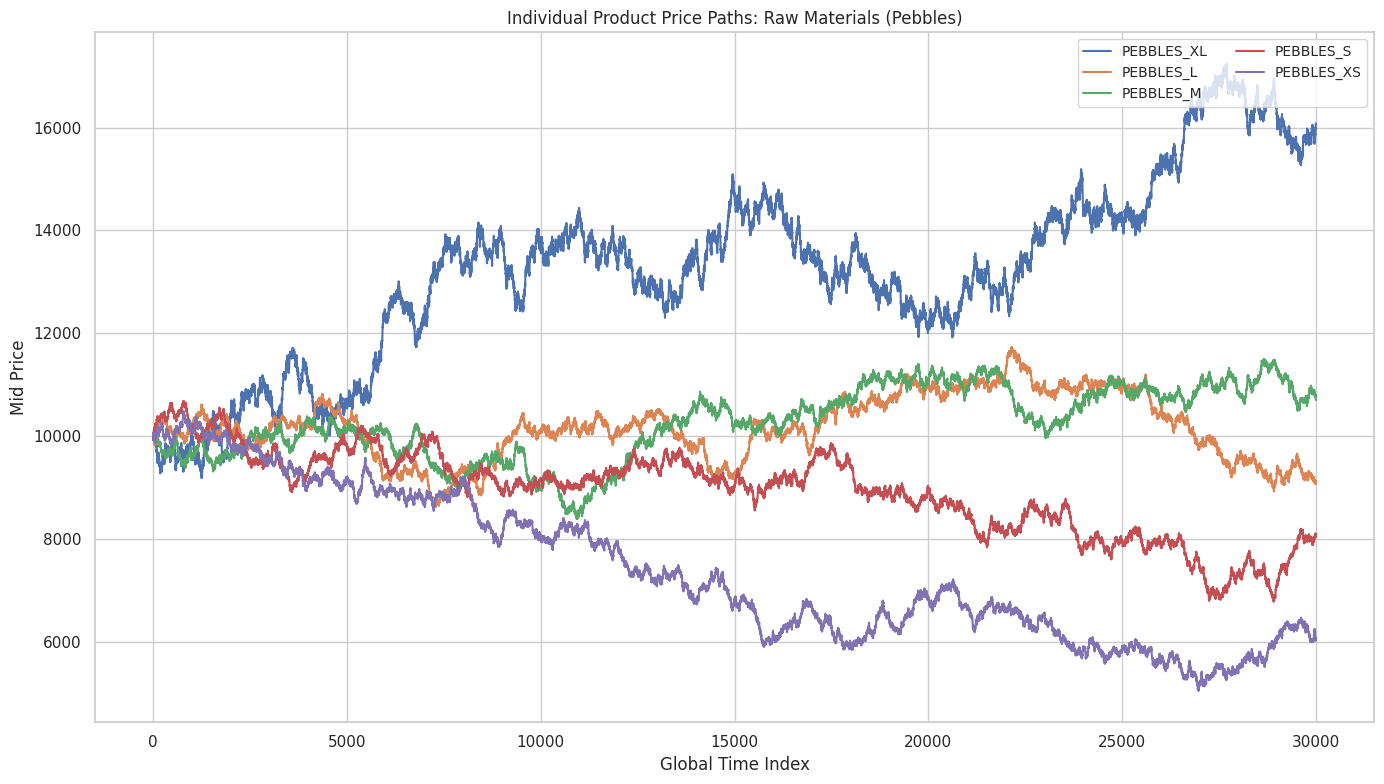

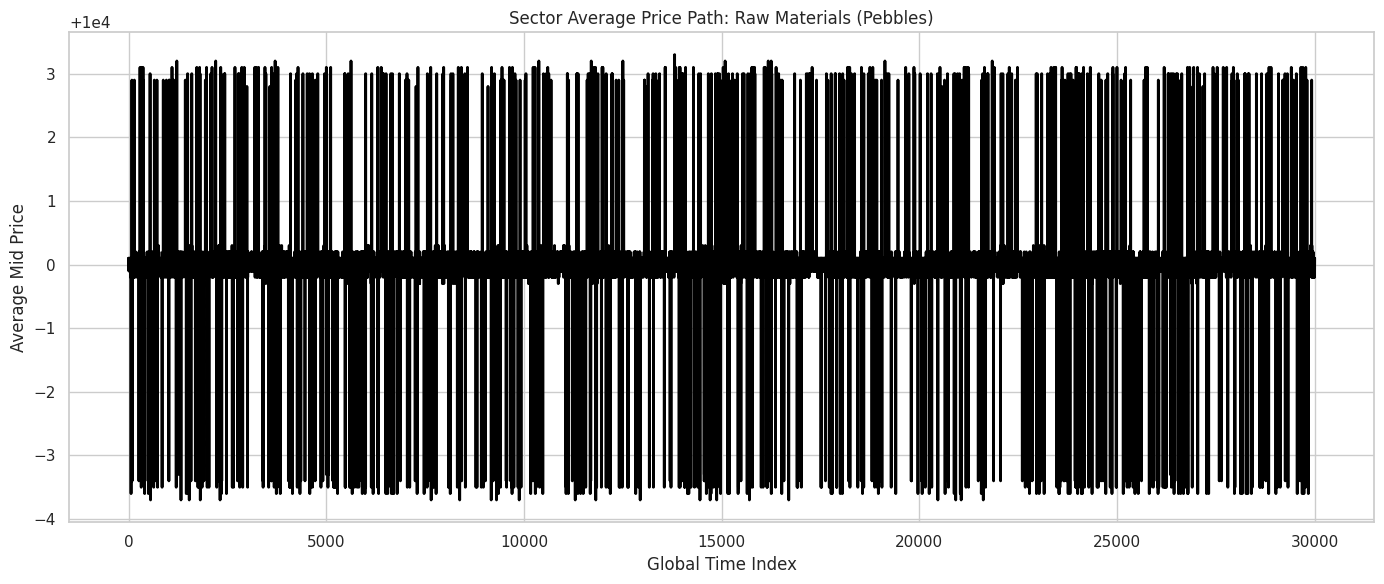

In [7]:
# Create a continuous time index across all days for each product
all_prices["global_time"] = all_prices.groupby("product").cumcount()

# Check which products exist in the data
existing_products = set(all_prices["product"].unique())
print("Existing products:", sorted(existing_products))

# Filter sectors to only include existing products
filtered_sectors = {}
for sector_name, products in sectors.items():
    filtered_products = [p for p in products if p in existing_products]
    if filtered_products:
        filtered_sectors[sector_name] = filtered_products
        print(f"{sector_name}: {len(filtered_products)} products - {filtered_products}")
    else:
        print(f"{sector_name}: No products found in data")

sectors = filtered_sectors

for sector_name, products in sectors.items():
    sector_data = all_prices[all_prices["product"].isin(products)]
    
    # Plot individual product paths
    plt.figure(figsize=(14, 8))
    for product in products:
        product_data = sector_data[sector_data["product"] == product].sort_values("global_time")
        if not product_data.empty:
            plt.plot(product_data["global_time"], product_data["mid_price"], label=product)
    plt.title(f"Individual Product Price Paths: {sector_name}")
    plt.xlabel("Global Time Index")
    plt.ylabel("Mid Price")
    plt.legend(loc="upper right", fontsize="small", ncol=2)
    plt.tight_layout()
    plt.show()
    
    # Plot sector average
    sector_avg = sector_data.groupby("global_time")["mid_price"].mean().reset_index()
    plt.figure(figsize=(14, 6))
    plt.plot(sector_avg["global_time"], sector_avg["mid_price"], color="black", linewidth=2)
    plt.title(f"Sector Average Price Path: {sector_name}")
    plt.xlabel("Global Time Index")
    plt.ylabel("Average Mid Price")
    plt.tight_layout()
    plt.show()

## Trade Data Analysis

Now we load and analyze the trade data from Round 5, including trade volumes, prices, and activity patterns across products and sectors.

In [ ]:
# Load trade data
trade_files = {
    2: "trades_round_5_day_2.csv",
    3: "trades_round_5_day_3.csv",
    4: "trades_round_5_day_4.csv",
}

all_trades = []
for day, file_name in trade_files.items():
    file_path = base_path / file_name
    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = df["timestamp"].astype(int)
    all_trades.append(df)

all_trades = pd.concat(all_trades, ignore_index=True)

# Rename symbol to product for consistency
all_trades = all_trades.rename(columns={"symbol": "product"})

all_trades.head()

In [5]:
print("Loaded trade data shape:", all_trades.shape)
print("Days in trade dataset:", sorted(all_trades["day"].unique()))
print("Unique products in trades:", all_trades["product"].nunique())
print("Total trade volume:", all_trades["quantity"].sum())
print("Average trade price:", all_trades["price"].mean())
print("Trades per day:")
print(all_trades.groupby("day").size())

NameError: name 'all_trades' is not defined

In [ ]:
# Aggregate trade volume by timestamp and day
trade_volume = all_trades.groupby(["day", "timestamp"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for idx, day in enumerate(sorted(trade_files)):
    ax = axes[idx]
    day_volume = trade_volume[trade_volume["day"] == day]
    ax.plot(day_volume["timestamp"], day_volume["quantity"], color="blue")
    ax.set_title(f"Total Trade Volume Over Time - Day {day}")
    ax.set_ylabel("Volume")
    if idx == 2:
        ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

In [ ]:
# Top traded products by volume
product_trade_volume = all_trades.groupby("product")["quantity"].sum().sort_values(ascending=False)
print("Top 10 products by trade volume:")
print(product_trade_volume.head(10))

# Plot top 10
top_products = product_trade_volume.head(10).index
fig, ax = plt.subplots(figsize=(12, 6))
product_trade_volume.head(10).plot(kind="bar", ax=ax)
ax.set_title("Top 10 Products by Total Trade Volume")
ax.set_xlabel("Product")
ax.set_ylabel("Total Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Add sector to trades
def get_sector(product):
    for sector_name, products in sectors.items():
        if product in products:
            return sector_name
    return "Unknown"

all_trades["sector"] = all_trades["product"].apply(get_sector)

# Sector trade volume
sector_volume = all_trades.groupby("sector")["quantity"].sum().sort_values(ascending=False)
print("Trade volume by sector:")
print(sector_volume)

# Plot sector volumes
fig, ax = plt.subplots(figsize=(12, 6))
sector_volume.plot(kind="bar", ax=ax)
ax.set_title("Trade Volume by Sector")
ax.set_xlabel("Sector")
ax.set_ylabel("Total Volume")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
# Compare trade prices to mid prices for a sample product
sample_product = product_trade_volume.index[0]  # Use top traded product

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
for idx, day in enumerate(sorted(price_files)):
    ax = axes[idx]
    
    # Mid prices
    day_prices = all_prices[(all_prices["day"] == day) & (all_prices["product"] == sample_product)]
    ax.plot(day_prices["timestamp"], day_prices["mid_price"], label="Mid Price", color="blue")
    
    # Trade prices
    day_trades = all_trades[(all_trades["day"] == day) & (all_trades["product"] == sample_product)]
    if not day_trades.empty:
        ax.scatter(day_trades["timestamp"], day_trades["price"], label="Trade Price", color="red", alpha=0.6, s=10)
    
    ax.set_title(f"{sample_product} - Day {day}: Mid Price vs Trade Prices")
    ax.set_ylabel("Price")
    ax.legend()
    if idx == 2:
        ax.set_xlabel("Timestamp")

plt.tight_layout()
plt.show()

## Trade Data Notes

- Trade data provides insights into actual market activity beyond order book mid-prices.
- High trade volumes indicate active products/sectors.
- Comparing trade prices to mid-prices can reveal execution quality and slippage.
- Sector analysis shows which categories are most traded.
- This complements the price path analysis for strategy development.